In [1]:
import sys
sys.path.append("../dev")          # make dev/ importable from notebooks/ (adjust if your cwd differs)

import numpy as np
import jax.numpy as jnp

from generate_synthetic_data import generate_raw_dataset, true_MWpLMC_potential

# Generate a fresh pool inline (~4 s for 300k, ~10 s for 1M). r_max=25 covers a
# heliocentric 15 kpc Gaia selection (R_sun ~8.2 + 15 ~23 kpc).
raw_datadict = generate_raw_dataset(
    true_MWpLMC_potential,
    n_train=1_000_000, n_test=200_000,
    r_max_train=25.0, r_max_test=30.0,
)

# --- OR, instead, load the big pool already saved by running the script once:
#     $ python dev/generate_synthetic_data.py
# raw_datadict = dict(np.load("../data/synthetic_data_raw_dict.npz"))

raw_datadict.keys()


dict_keys(['x_train', 'a_train', 'u_train', 'r_train', 'x_val', 'a_val', 'u_val', 'r_val'])

In [2]:
from utils_pablo import generate_observers_dataset

observer_position = jnp.array([-8.2, 0.0, 0.0])   # Sun, galactocentric kpc

obs_dataset = generate_observers_dataset(
    raw_datadict,
    observer_position=observer_position,
    r_accel_meas=4,      # pulsars: within 4 kpc of the Sun
    r_pos_meas=15,       # Gaia: within 15 kpc of the Sun
    n_acc=50,            # few acceleration measurements
    n_pos=100_000,       # many positions (must be <= points within r_pos_meas)
)
obs_dataset.keys()


22,446/1,000,000 training samples within 4 kpc of the observer.
Sampling 50 acceleration measurements.
497,909/1,000,000 training samples within 15 kpc of the observer.
Sampling 100000 position-only measurements.

Validation: 3,485 samples within 4 kpc, 80,863 samples within 15 kpc.


dict_keys(['x_acc_train', 'a_acc_train', 'x_pos_train', 'x_acc_val', 'a_acc_val', 'x_pos_val', 'n_vecs', 'a_los'])

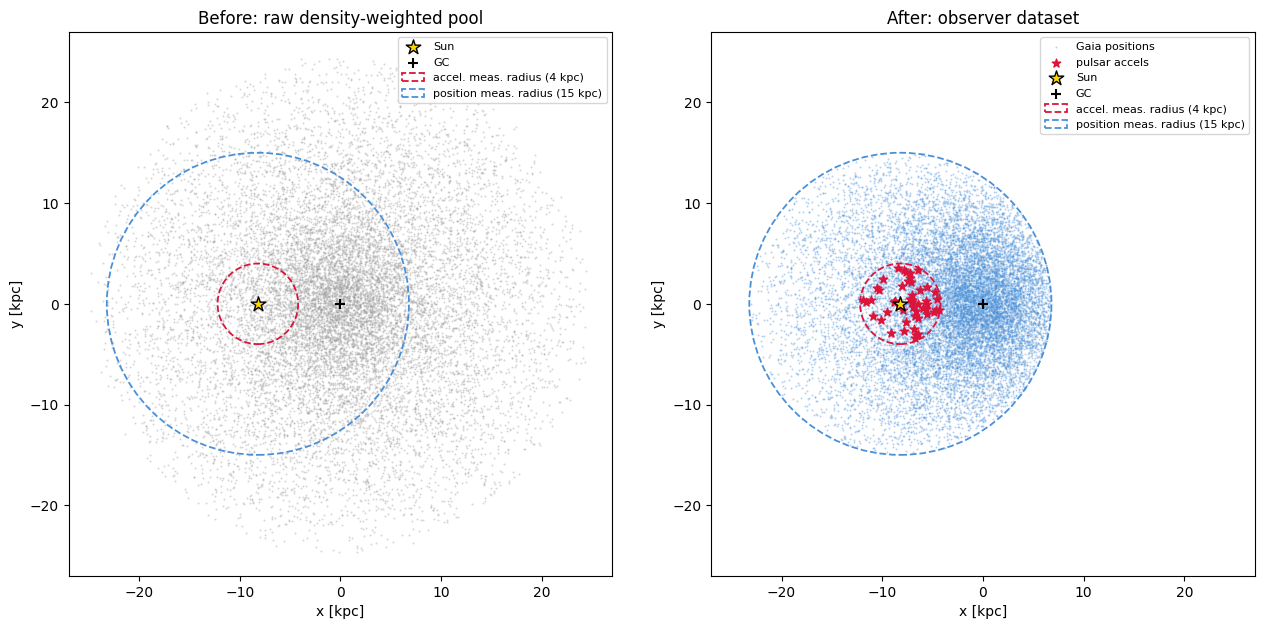

In [3]:
import matplotlib.pyplot as plt

def _sub(a, k=15000, seed=0):
    """Subsample rows so the scatter stays light (millions of points are slow to draw)."""
    a = np.asarray(a)
    if a.shape[0] <= k:
        return a
    idx = np.random.default_rng(seed).choice(a.shape[0], k, replace=False)
    return a[idx]

sun = np.asarray(observer_position)
r_acc, r_pos = 4, 15

fig, ax = plt.subplots(1, 2, figsize=(13, 6.2))

# Before: the raw density-weighted pool
raw_xy = _sub(raw_datadict["x_train"])
ax[0].scatter(raw_xy[:, 0], raw_xy[:, 1], s=2, c="0.6", alpha=0.4, lw=0)
ax[0].set_title("Before: raw density-weighted pool")

# After: the observer dataset
pos_xy = _sub(obs_dataset["x_pos_train"])
acc_xy = np.asarray(obs_dataset["x_acc_train"])
ax[1].scatter(pos_xy[:, 0], pos_xy[:, 1], s=2, c="#4a90d9", alpha=0.4, lw=0, label="Gaia positions")
ax[1].scatter(acc_xy[:, 0], acc_xy[:, 1], s=40, c="crimson", marker="*", zorder=5, label="pulsar accels")
ax[1].set_title("After: observer dataset")

for a in ax:
    a.scatter([sun[0]], [sun[1]], s=120, marker="*", c="gold", edgecolor="k", zorder=6, label="Sun")
    a.scatter([0], [0], s=60, marker="+", c="k", zorder=6, label="GC")
    a.add_patch(plt.Circle((sun[0], sun[1]), r_acc, fill=False, ls="--", ec="crimson", lw=1.3,
                           label=f"accel. meas. radius ({r_acc} kpc)"))
    a.add_patch(plt.Circle((sun[0], sun[1]), r_pos, fill=False, ls="--", ec="#4a90d9", lw=1.3,
                           label=f"position meas. radius ({r_pos} kpc)"))

    a.set_aspect("equal"); a.set_xlim(-27, 27); a.set_ylim(-27, 27)
    a.set_xlabel("x [kpc]"); a.set_ylabel("y [kpc]")
    a.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


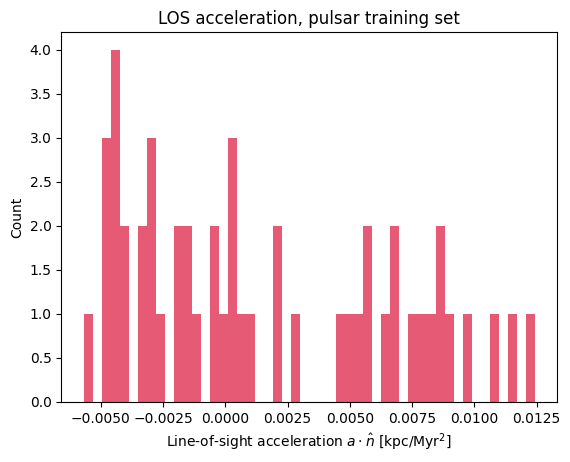

In [4]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

observer_position = jnp.array([-8.2, 0.0, 0.0])   # Sun — same point used to build obs_dataset

a = obs_dataset["a_acc_train"]     # (N, 3) accelerations, GC frame [kpc/Myr²]
x = obs_dataset["x_acc_train"]     # (N, 3) positions,     GC frame [kpc]

dx     = x - observer_position                              # Sun -> pulsar
n_vecs = dx / jnp.linalg.norm(dx, axis=1, keepdims=True)    # (N, 3) unit sightlines
a_los  = jnp.sum(a * n_vecs, axis=1)                        # (N,)  a · n̂

plt.hist(a_los, bins=50, color="crimson", alpha=0.7)
plt.xlabel(r"Line-of-sight acceleration $a\cdot\hat n$ [kpc/Myr$^2$]")
plt.ylabel("Count")
plt.title("LOS acceleration, pulsar training set")
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

# Kepler field center (Cygnus/Lyra), Galactic coords
l_kep, b_kep = np.deg2rad(76.32), np.deg2rad(13.5)
n_hat = np.array([np.cos(b_kep)*np.cos(l_kep),   # +x toward GC
                  np.cos(b_kep)*np.sin(l_kep),   # +y toward rotation
                  np.sin(b_kep)])                # +z toward N gal. pole
# -> n_hat ≈ (0.23, 0.94, 0.23): mostly +y, tilted 13.5° out of the disk


In [6]:
rng = np.random.default_rng(0)
N, alpha = 400, np.deg2rad(7.0)
d = np.clip(rng.lognormal(np.log(1.0), 0.55, N), 0.2, 5.0)   # kpc, Sun-EB distance

e1 = np.cross(n_hat, [0,0,1.]); e1 /= np.linalg.norm(e1)      # basis in the FoV plane
e2 = np.cross(n_hat, e1)
th, ph = alpha*np.sqrt(rng.random(N)), 2*np.pi*rng.random(N)
dirs = (np.cos(th)[:,None]*n_hat
        + (np.sin(th)*np.cos(ph))[:,None]*e1
        + (np.sin(th)*np.sin(ph))[:,None]*e2)
eb = np.asarray(sun) + d[:,None]*dirs                        # (N,3) galactocentric kpc


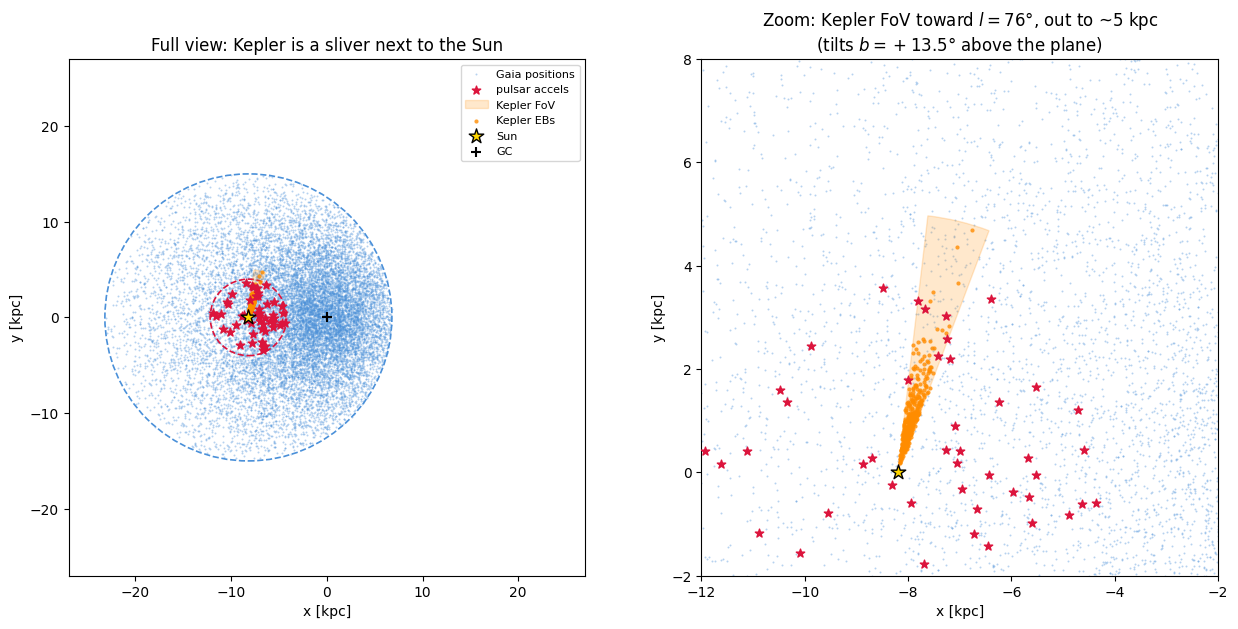

In [7]:
phi0 = np.rad2deg(np.arctan2(n_hat[1], n_hat[0]))    # 76.3° projected into x-y
sun2 = np.asarray(sun)[:2]

fig, ax = plt.subplots(1, 2, figsize=(13, 6.2))

for a in ax:
    a.scatter(*_sub(obs_dataset["x_pos_train"])[:, :2].T, s=2, c="#4a90d9", alpha=0.4, lw=0, label="Gaia positions")
    a.scatter(*np.asarray(obs_dataset["x_acc_train"])[:, :2].T, s=40, c="crimson", marker="*", zorder=5, label="pulsar accels")
    a.add_patch(Wedge(sun2, 5.0, phi0-7, phi0+7, color="darkorange", alpha=0.20, zorder=3, label="Kepler FoV"))
    a.scatter(eb[:, 0], eb[:, 1], s=9, c="darkorange", alpha=0.8, lw=0, zorder=4, label="Kepler EBs")
    a.scatter([sun2[0]], [sun2[1]], s=120, marker="*", c="gold", edgecolor="k", zorder=6, label="Sun")
    a.scatter([0], [0], s=60, marker="+", c="k", zorder=6, label="GC")
    a.set_aspect("equal"); a.set_xlabel("x [kpc]"); a.set_ylabel("y [kpc]")

ax[0].add_patch(plt.Circle(sun2, 15, fill=False, ls="--", ec="#4a90d9", lw=1.2))
ax[0].add_patch(plt.Circle(sun2, 4,  fill=False, ls="--", ec="crimson", lw=1.2))
ax[0].set_xlim(-27, 27); ax[0].set_ylim(-27, 27)
ax[0].set_title("Full view: Kepler is a sliver next to the Sun")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].set_xlim(-12, -2); ax[1].set_ylim(-2, 8)     # zoom on the solar neighborhood
ax[1].set_title("Zoom: Kepler FoV toward $l{=}76°$, out to ~5 kpc\n(tilts $b{=}+13.5°$ above the plane)")

plt.tight_layout(); plt.show()
